# Neural Network for Win Probability Prediction / Classification

In this notebook, we will create a simple fully connected neural network using Pytorch. We will evaluate the quality of the model when trained on the three different datasets.

# 1. Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import copy
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from utils import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")

df = pd.read_csv("../Data/full_data_enc.csv")
df_odds = pd.read_csv("../Data/odds_data_enc.csv")
df_nodds = pd.read_csv("../Data/nodds_data_enc.csv")

df.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age_c,age_c_sq,is_outdoor,...,Masters Cup,Clay,Grass,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,-9.817933,96.391807,1,...,0,1,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,-9.765914,95.373072,1,...,0,0,0,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,-9.724846,94.572630,1,...,0,0,0,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,-9.716632,94.412946,1,...,0,0,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,-9.711157,94.306565,1,...,0,0,0,0,1,0,0,0,0,0


Now that we have our data loaded, we can split our data, separate the target variable from predictors, standardise the matrices, and form the tensors we need for pytorch to be able to handle our data.

In [2]:
# Train test split
df_train_full, df_test_full = chrono_split_df(df, 0.8)
df_train_full, df_val_full = chrono_split_df(df_train_full, 0.8)

df_train_odds, df_test_odds = chrono_split_df(df_odds, 0.8)
df_train_odds, df_val_odds = chrono_split_df(df_train_odds, 0.8)

df_train_nodds, df_test_nodds = chrono_split_df(df_nodds, 0.8)
df_train_nodds, df_val_nodds = chrono_split_df(df_train_nodds, 0.8)

In [3]:
# Separating target from predictors
y_train_full, y_val_full, y_test_full = df_train_full["dj_win"].to_numpy().reshape(-1, 1), df_val_full["dj_win"].to_numpy().reshape(-1, 1), df_test_full["dj_win"].to_numpy().reshape(-1, 1)
X_train_full, X_val_full, X_test_full = df_train_full.copy().drop(columns="dj_win").to_numpy(), df_val_full.drop(columns="dj_win").to_numpy(), df_test_full.drop(columns="dj_win").to_numpy()

y_train_odds, y_val_odds, y_test_odds = df_train_odds["dj_win"].to_numpy().reshape(-1, 1), df_val_odds["dj_win"].to_numpy().reshape(-1, 1), df_test_odds["dj_win"].to_numpy().reshape(-1, 1)
X_train_odds, X_val_odds, X_test_odds = df_train_odds.copy().drop(columns="dj_win").to_numpy(), df_val_odds.drop(columns="dj_win").to_numpy(), df_test_odds.drop(columns="dj_win").to_numpy()

y_train_nodds, y_val_nodds, y_test_nodds = df_train_nodds["dj_win"].to_numpy().reshape(-1, 1), df_val_nodds["dj_win"].to_numpy().reshape(-1, 1), df_test_nodds["dj_win"].to_numpy().reshape(-1, 1)
X_train_nodds, X_val_nodds, X_test_nodds = df_train_nodds.copy().drop(columns="dj_win").to_numpy(), df_val_nodds.drop(columns="dj_win").to_numpy(), df_test_nodds.drop(columns="dj_win").to_numpy()

In [4]:
# Standardise prediction matrices
X_train_std_full = standardise_cols(X_train_full, np.arange(0, X_train_full.shape[1]))
X_val_std_full = standardise_cols(X_val_full, np.arange(0, X_val_full.shape[1]), X_train_full)
X_test_std_full = standardise_cols(X_test_full, np.arange(0, X_test_full.shape[1]), X_train_full)

X_train_std_odds = standardise_cols(X_train_odds, np.arange(0, X_train_odds.shape[1]))
X_val_std_odds = standardise_cols(X_val_odds, np.arange(0, X_val_odds.shape[1]), X_train_odds)
X_test_std_odds = standardise_cols(X_test_odds, np.arange(0, X_test_odds.shape[1]), X_train_odds)

X_train_std_nodds = standardise_cols(X_train_nodds, np.arange(0, X_train_nodds.shape[1]))
X_val_std_nodds = standardise_cols(X_val_nodds, np.arange(0, X_val_nodds.shape[1]), X_train_nodds)
X_test_std_nodds = standardise_cols(X_test_nodds, np.arange(0, X_test_nodds.shape[1]), X_train_nodds)

In [5]:
# Forming tensors for PyTorch

# Full Dataset
X_train_t_full = torch.tensor(X_train_std_full, dtype=torch.float32)
y_train_t_full = torch.tensor(y_train_full, dtype=torch.float32)

X_val_t_full = torch.tensor(X_val_std_full, dtype=torch.float32)
y_val_t_full = torch.tensor(y_val_full, dtype=torch.float32)

X_test_t_full = torch.tensor(X_test_std_full, dtype=torch.float32)
y_test_t_full = torch.tensor(y_test_full, dtype=torch.float32)

# Odds Dataset
X_train_t_odds = torch.tensor(X_train_std_odds, dtype=torch.float32)
y_train_t_odds = torch.tensor(y_train_odds, dtype=torch.float32)

X_val_t_odds = torch.tensor(X_val_std_odds, dtype=torch.float32)
y_val_t_odds = torch.tensor(y_val_odds, dtype=torch.float32)

X_test_t_odds = torch.tensor(X_test_std_odds, dtype=torch.float32)
y_test_t_odds = torch.tensor(y_test_odds, dtype=torch.float32)

# No Odds Dataset
X_train_t_nodds = torch.tensor(X_train_std_nodds, dtype=torch.float32)
y_train_t_nodds = torch.tensor(y_train_nodds, dtype=torch.float32)

X_val_t_nodds = torch.tensor(X_val_std_nodds, dtype=torch.float32)
y_val_t_nodds = torch.tensor(y_val_nodds, dtype=torch.float32)

X_test_t_nodds = torch.tensor(X_test_std_nodds, dtype=torch.float32)
y_test_t_nodds = torch.tensor(y_test_nodds, dtype=torch.float32)

# 2. Creating Networks

Having loaded the data we need, we will now create our neural network, and specifiy loss and optimiser before we begin to train our networks and assess their performances.

In [6]:
g = torch.Generator().manual_seed(SEED)

train_ds_full = TensorDataset(X_train_t_full, y_train_t_full)
train_loader_full = DataLoader(train_ds_full, batch_size=64, shuffle=True, generator=g)

train_ds_odds = TensorDataset(X_train_t_odds, y_train_t_odds)
train_loader_odds = DataLoader(train_ds_odds, batch_size=64, shuffle=True, generator=g)

train_ds_nodds = TensorDataset(X_train_t_nodds, y_train_t_nodds)
train_loader_nodds = DataLoader(train_ds_nodds, batch_size=64, shuffle=True, generator=g)

In [7]:
class NeuralNetwork(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(features, 32),
            nn.ReLU(),
            nn.Linear(32, 1))

    def forward(self, X):
        logits = self.layer(X)
        return torch.sigmoid(logits) # returns probabilities

In [8]:
model_full  = NeuralNetwork(X_train_t_full.shape[1])
model_odds  = NeuralNetwork(X_train_t_odds.shape[1])
model_nodds = NeuralNetwork(X_train_t_nodds.shape[1])
print(model_full)

NeuralNetwork(
  (layer): Sequential(
    (0): Linear(in_features=24, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


# 3. Training and Evaluating the Models

Now that we have formed the architecture we will use for our models, we can begin training them and comparing their performances. We first define a training loop and optimisers, before actually carrying out the training and plotting our the loss curves.

In [9]:
def train(dataloader, model, loss, optim, epochs, X_val, y_val):

    train_losses = []
    val_losses = []
    best_val, best_state, patience, no_improve = float("inf"), None, 50, 0

    for epoch in range(epochs):

        if (epoch + 1) % 50 == 0:
            print("Epoch number", epoch + 1)
        batch_losses = []
        model.train()

        for (X, y) in dataloader:

            optim.zero_grad()
            batch_loss = loss(model.forward(X), y)
            batch_losses.append(batch_loss.item())
            batch_loss.backward()
            optim.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss(model.forward(X_val), y_val).item()

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val, best_state, no_improve, best_epoch = val_loss, copy.deepcopy(model.state_dict()), 0, epoch

        else:
            no_improve += 1
            if no_improve > patience:
                break
    
    print("Training Finished")

    model.load_state_dict(best_state)

    return train_losses, val_losses, best_epoch

In [10]:
opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-3)
opt_odds = torch.optim.Adam(model_odds.parameters(), lr=1e-3)
opt_nodds = torch.optim.Adam(model_nodds.parameters(), lr=1e-3)

loss = nn.BCELoss()

In [11]:
print("Full model:")
train_losses_full, val_losses_full, best_epoch_full = train(train_loader_full, model_full, loss, opt_full, 1000, X_val_t_full, y_val_t_full)
print("")
print("Odds Only Model:")
train_losses_odds, val_losses_odds, best_epoch_odds = train(train_loader_odds, model_odds, loss, opt_odds, 1000, X_val_t_odds, y_val_t_odds)
print("")
print("No Odds Model:")
train_losses_nodds, val_losses_nodds, best_epoch_nodds = train(train_loader_nodds, model_nodds, loss, opt_nodds, 1000, X_val_t_nodds, y_val_t_nodds)

Full model:
Epoch number 50
Training Finished

Odds Only Model:
Epoch number 50
Epoch number 100
Epoch number 150
Epoch number 200
Epoch number 250
Epoch number 300
Training Finished

No Odds Model:
Epoch number 50
Training Finished


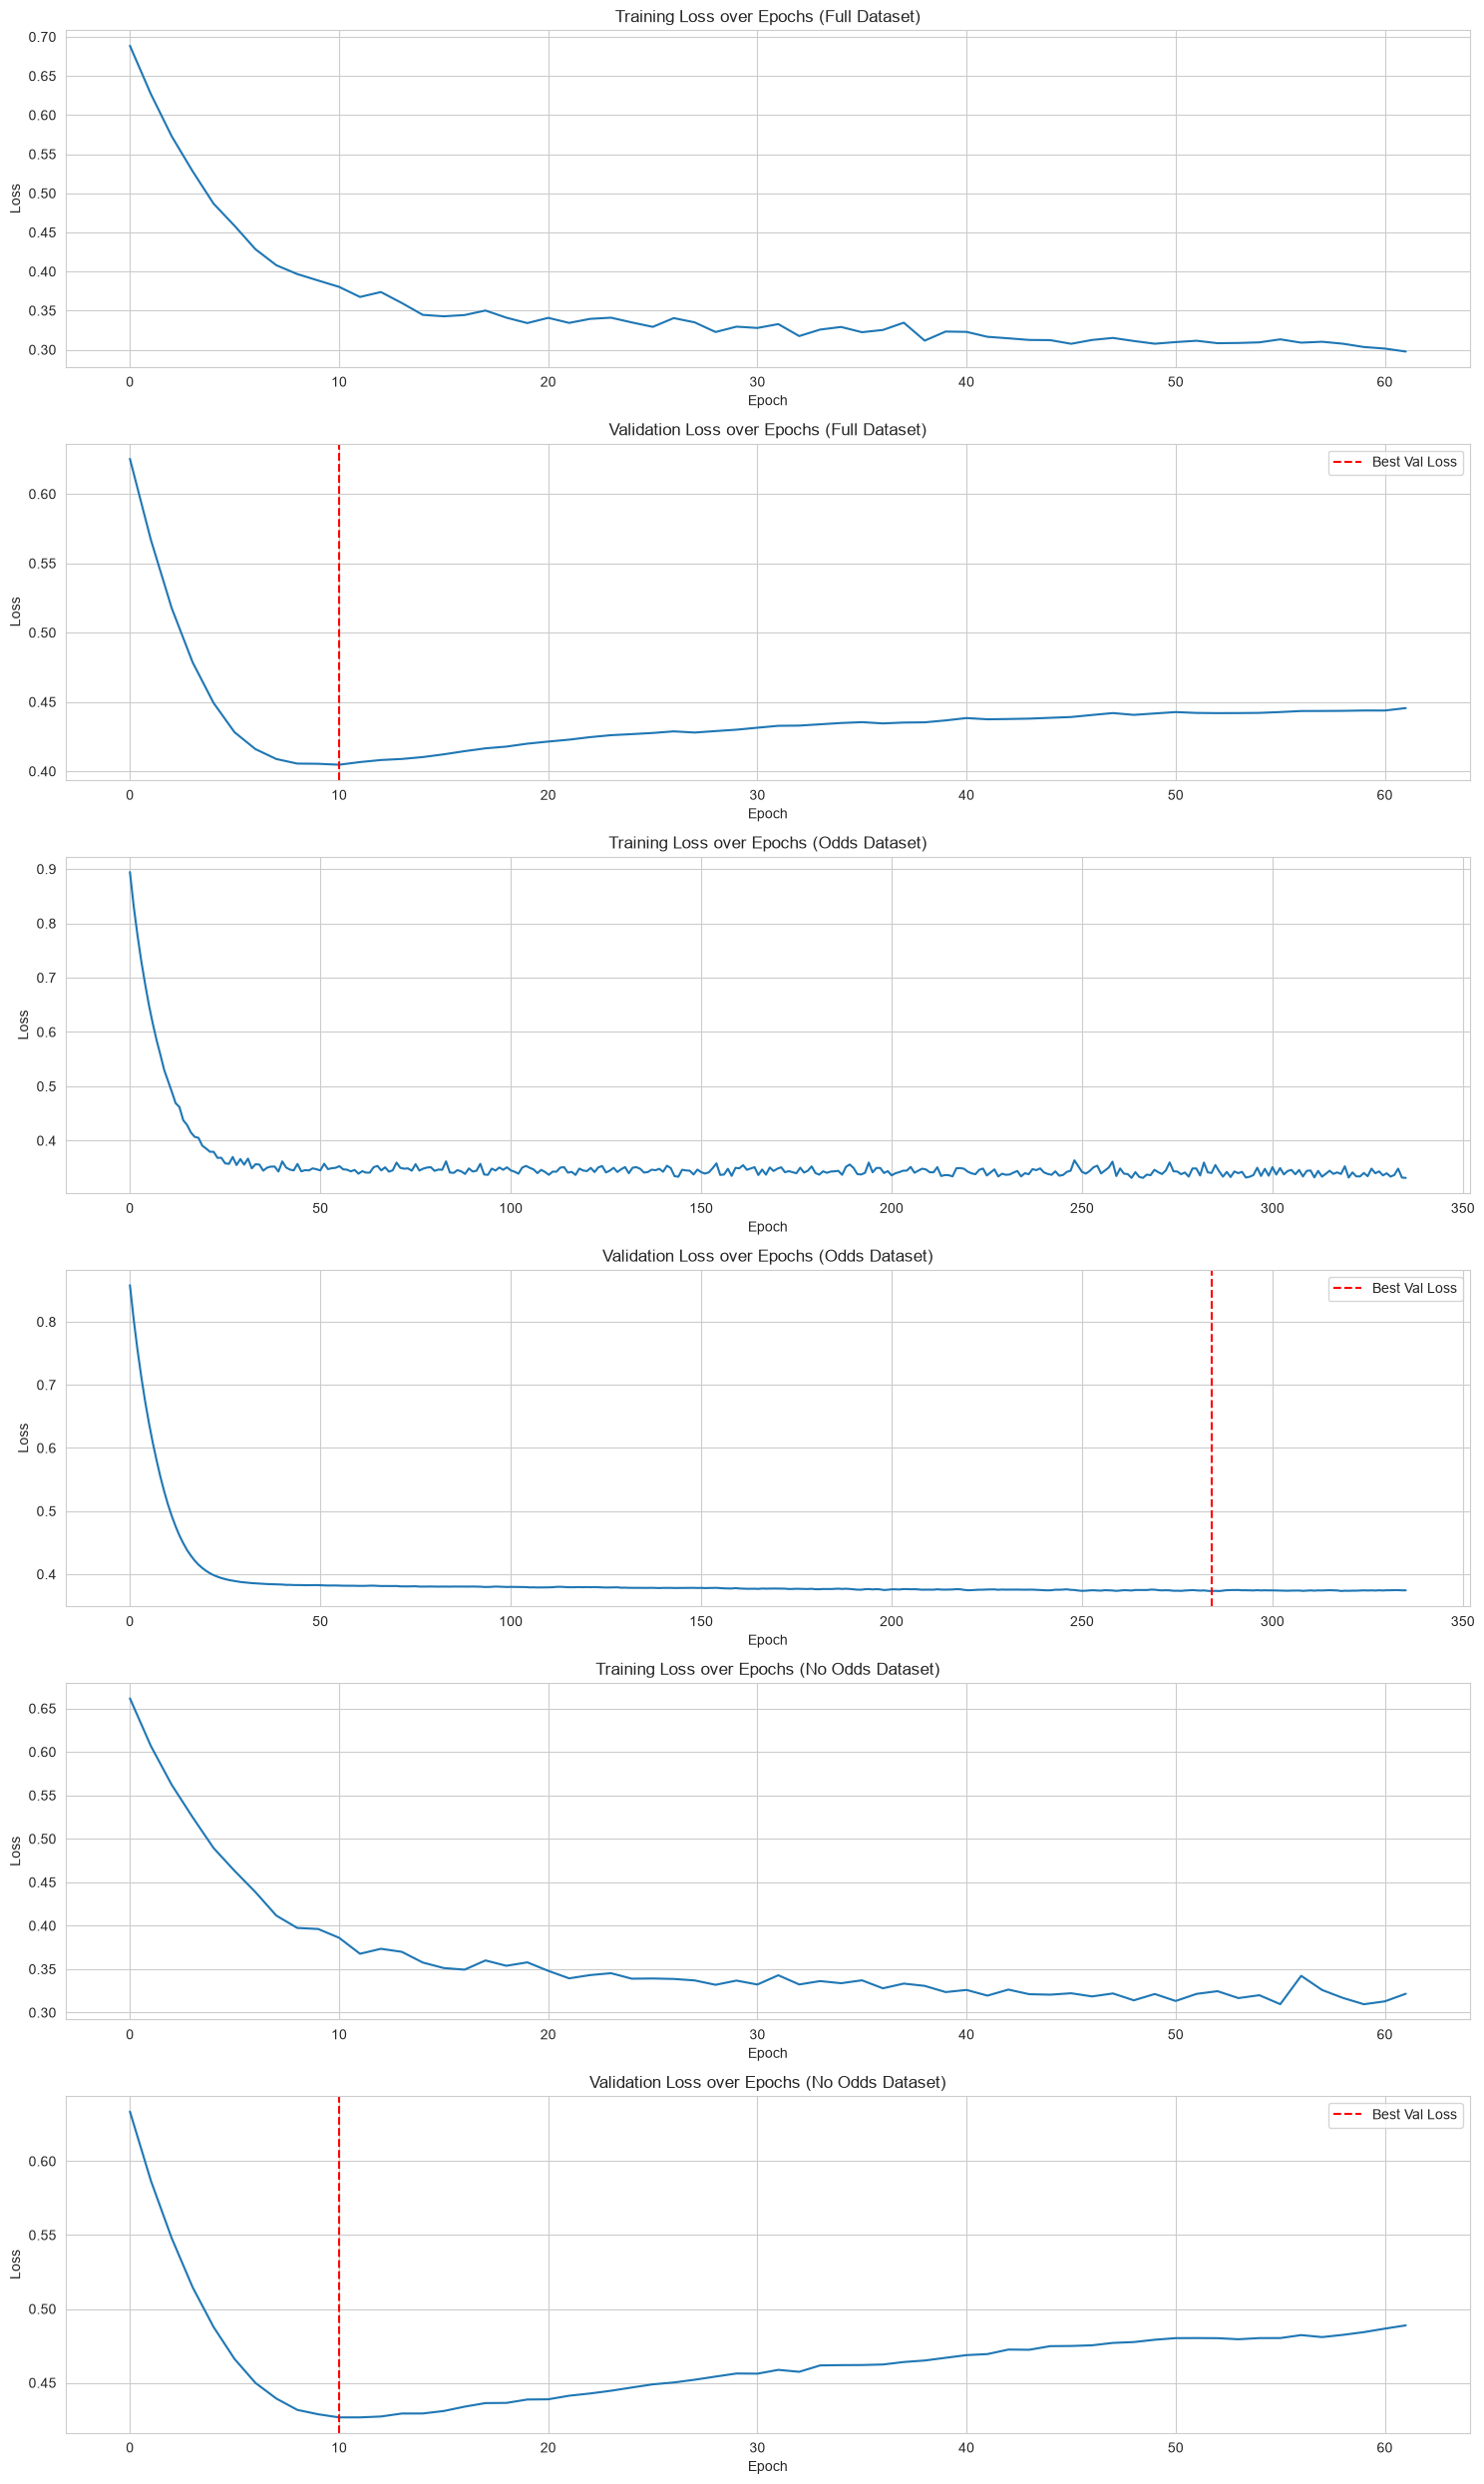

In [12]:
fig, ax = plt.subplots(6, 1, figsize=(15, 25))

ax[0].plot(train_losses_full)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss over Epochs (Full Dataset)")

ax[1].plot(val_losses_full)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Validation Loss over Epochs (Full Dataset)")
ax[1].axvline(best_epoch_full, color="Red", linestyle="--", label="Best Val Loss")
ax[1].legend()

ax[2].plot(train_losses_odds)
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
ax[2].set_title("Training Loss over Epochs (Odds Dataset)")

ax[3].plot(val_losses_odds)
ax[3].set_xlabel("Epoch")
ax[3].set_ylabel("Loss")
ax[3].set_title("Validation Loss over Epochs (Odds Dataset)")
ax[3].axvline(best_epoch_odds, color="Red", linestyle="--", label="Best Val Loss")
ax[3].legend()

ax[4].plot(train_losses_nodds)
ax[4].set_xlabel("Epoch")
ax[4].set_ylabel("Loss")
ax[4].set_title("Training Loss over Epochs (No Odds Dataset)")

ax[5].plot(val_losses_nodds)
ax[5].set_xlabel("Epoch")
ax[5].set_ylabel("Loss")
ax[5].set_title("Validation Loss over Epochs (No Odds Dataset)")
ax[5].axvline(best_epoch_nodds, color="Red", linestyle="--", label="Best Val Loss")
ax[5].legend()

plt.tight_layout()
plt.show()

# 4. Model Evaluation

Now, let us evaluate how each of our models performs, so that we can do some comparison between them.

In [13]:
probs_val = model_full.forward(X_val_t_full)
y_pred = (probs_val >= 0.5).float()

In [14]:
def confusion_matrix(y_pred, y):

    aa = torch.sum((y_pred == 1) & (y == 1))
    ab = torch.sum((y_pred == 1) & (y == 0))
    ba = torch.sum((y_pred == 0) & (y == 1))
    bb = torch.sum((y_pred == 0) & (y == 0))

    return np.array([[aa, ab], 
                    [ba, bb]])

In [15]:
def performance_analysis(model, X_test, y_test):
    probs = model.forward(X_test)
    y_pred = (probs >= 0.5).float()
    acc = torch.mean((y_pred == y_test).float())

    mat = confusion_matrix(y_pred, y_test)
    positive_precision = mat[0, 0] / (mat[0, 0] + mat[0, 1]) if (mat[0, 0] + mat[0, 1]) else 0.0
    positive_recall = mat[0, 0] / (mat[0, 0] + mat[1, 0]) if (mat[0, 0] + mat[1, 0]) else 0.0
    negative_precision = mat[1, 1] / (mat[1, 0] + mat[1, 1]) if (mat[1, 0] + mat[1, 1]) else 0.0
    negative_recall = mat[1, 1] / (mat[1, 1] + mat[0, 1]) if (mat[1, 1] + mat[0, 1]) else 0.0

    print("Performance Analysis")
    print("-" * 30)
    print(f"Confusion matrix: {mat}")
    print(f"Positive Precision: {positive_precision :.4f}")
    print(f"Negative Precision: {negative_precision :.4f}")
    print(f"Positive Recall: {positive_recall:.4f}")
    print(f"Negative Recall: {negative_recall:.4f}")
    print(f"Accuracy: {acc:.4f}")

In [16]:
print("FULL DATASET:")
performance_analysis(model_full, X_test_t_full, y_test_t_full)
print("")
print("ODDS DATASET:")
performance_analysis(model_odds, X_test_t_odds, y_test_t_odds)
print("")
print("NO ODDS DATASET:")
performance_analysis(model_nodds, X_test_t_nodds, y_test_t_nodds)

FULL DATASET:
Performance Analysis
------------------------------
Confusion matrix: [[207  36]
 [  1   4]]
Positive Precision: 0.8519
Negative Precision: 0.8000
Positive Recall: 0.9952
Negative Recall: 0.1000
Accuracy: 0.8508

ODDS DATASET:
Performance Analysis
------------------------------
Confusion matrix: [[206  35]
 [  2   5]]
Positive Precision: 0.8548
Negative Precision: 0.7143
Positive Recall: 0.9904
Negative Recall: 0.1250
Accuracy: 0.8508

NO ODDS DATASET:
Performance Analysis
------------------------------
Confusion matrix: [[208  40]
 [  0   0]]
Positive Precision: 0.8387
Negative Precision: 0.0000
Positive Recall: 1.0000
Negative Recall: 0.0000
Accuracy: 0.8387


The bottom row of the confusion matrix of the no odds model indicates that it never attempts to predict a loss and has converted to the win-predictor model. Its accuracy of $83.87\%$ is the exact same as the win-predictor.

The accuracy is best for the odds model out of all models, also with the best negative recall, indicating that it has made the best attempt to learn loss signal.

In [17]:
def sweep_threshold(probs, y, thresholds=np.linspace(0.01, 0.99, 99)):
    probs, y = probs.ravel(), y.ravel()
    best_t, best_score, rows = 0.5, -1.0, []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (y == 1)).sum()
        tn = ((preds == 0) & (y == 0)).sum()
        fp = ((preds == 1) & (y == 0)).sum()
        fn = ((preds == 0) & (y == 1)).sum()
        tpr = tp / (tp + fn) if (tp + fn) else 0.0
        tnr = tn / (tn + fp) if (tn + fp) else 0.0
        score = 0.5 * (tpr + tnr)
        rows.append((t, tpr, tnr, score))
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score, rows

In [18]:
best_t_full, best_score_full, rows_full = sweep_threshold(probs_val.detach().numpy(), y_val_t_full.detach().numpy())

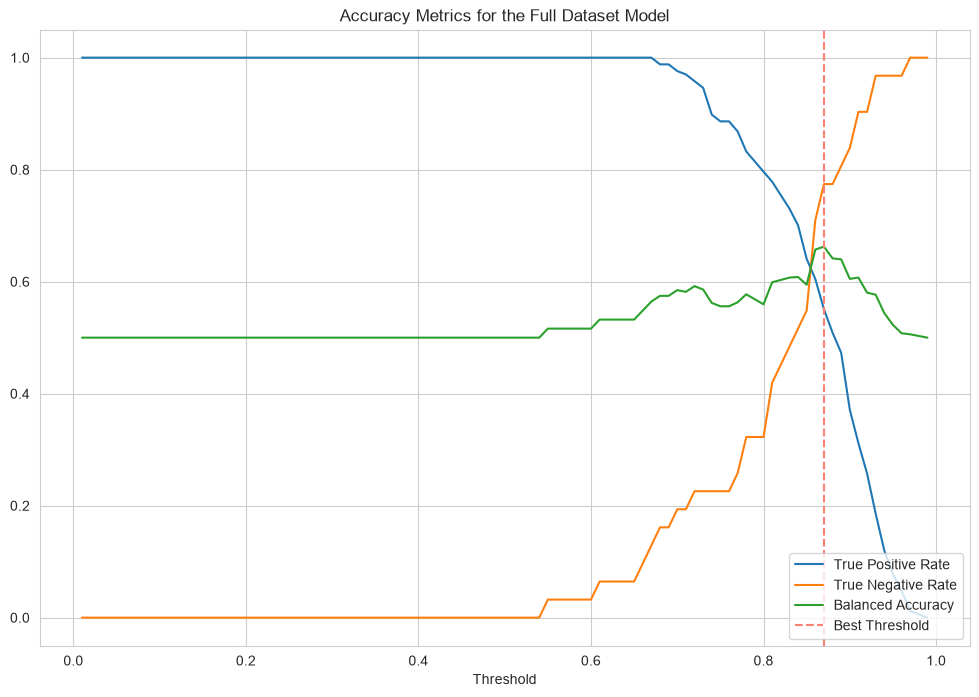

In [19]:
rows_full = np.array(rows_full)

plt.figure(figsize=(12, 8))
plt.title("Accuracy Metrics for the Full Dataset Model")
plt.plot(rows_full[:, 0], rows_full[:, 1], label="True Positive Rate")
plt.plot(rows_full[:, 0], rows_full[:, 2], label="True Negative Rate")
plt.plot(rows_full[:, 0], rows_full[:, 3], label="Balanced Accuracy")
plt.axvline(best_t_full, color="Salmon", linestyle="--", label="Best Threshold")
plt.legend()
plt.xlabel("Threshold")
plt.show()

In [20]:
print(f"Best threshold on validation: {best_t_full:.2f} (balanced accuracy {best_score_full:.3f})")
probs_test_full = model_full(X_test_t_full).detach().numpy()
preds = (probs_test_full.ravel() >= best_t_full).astype(int)
print(f"At that threshold — loss recall: {((preds==0) & (y_test_full.ravel()==0)).sum() / (y_test_full==0).sum():.3f}")

Best threshold on validation: 0.87 (balanced accuracy 0.663)
At that threshold — loss recall: 0.950


Let us now calculate the test binary cross entropies, which allow us to compare the models' probability predictions instead of just the classification labels they land on and how accurate they are.

In [21]:
model_full.eval()
with torch.no_grad():
    test_bce_full = loss(model_full(X_test_t_full), y_test_t_full).item()

model_odds.eval()
with torch.no_grad():
    test_bce_odds = loss(model_odds(X_test_t_odds), y_test_t_odds).item()

model_nodds.eval()
with torch.no_grad():
    test_bce_nodds = loss(model_nodds(X_test_t_nodds), y_test_t_nodds).item()

In [22]:
print(f"Test loss for odds dataset: {test_bce_odds}")
print(f"Test loss for full dataset: {test_bce_full}")
print(f"Test loss for no odds dataset: {test_bce_nodds}")

Test loss for odds dataset: 0.3922932744026184
Test loss for full dataset: 0.390868216753006
Test loss for no odds dataset: 0.42740607261657715


Again, the odds-only model has the best performance, followed by the no odds dataset, then the full dataset. Again, just as in the logistic regression, introducing our chosen features actually worsens the performance of the odds-only model.

# 5. Discussion

#### Results Summary

| Model (dataset)     | Test BCE | Test accuracy | Win recall | Loss recall | Win precision |
|---------------------|----------|---------------|------------|-------------|---------------|
| Odds only           | 0.3846   | 85.48%        | 0.990      | 0.150       | 0.858         |
| Full (all features) | 0.4073   | 85.08%        | 0.995      | 0.100       | 0.852         |
| No odds             | 0.4062   | 83.87%        | 1.000      | 0.000       | 0.839         |
| *Base-rate baseline*| *0.4419* | *83.87%*      | *1.000*    | *0.000*     | *0.839*       |

In this notebook, we trained three neural networks with the same architectures to compare the performance when trained on different datasets. As we can see, the models performed relatively similarly in terms of accuracy metrics, with the model trained on the odds-only dataset performing noticeably better in terms of BCE, indicating a better calibration of predicted probabilities. We can see that the win precision is good across the board, with good positive recall but very poor negative recall. This is due to the class imbalance. Djokovic wins roughly 84% of matches, so a 0.5 threshold is badly matched to the problem: even matches the model rates as relatively weak still receive probabilities above 0.5, and are labelled wins. The threshold sweep shows the loss signal is in fact there — at a threshold of 0.88, chosen on the validation set, the full model recovers 77.5% of losses. The default 0.5 cut maximises accuracy, which on an 84/16 split means predicting the majority class almost always; catching losses requires trading accuracy for loss recall, and where that trade should sit is an application decision rather than a property of the model.

We note that the odds-only model clearly performs better than the other two, which perform very similarly. This supports the fact that odds is the feature with the best explanatory power to the target variable. Furthermore, we have a test BCE of $\approx 0.4073$ on the full model, and $\approx 0.3846$ on the odds-only model, again indicating that adding the additional features may actually slightly muddy the signal given by the odds data, by introducing more variation and noise. 

Furthermore, our odds metric results are quite similar to the logistic regression. This indicates that the odds-to-outcome relationship is essentially linear and the additional exploitation of non-linearity that the extra capacity of a neural network provides, does not give any further benefit.